In [4]:
from common_functions import reduce
from astropy.io import fits
from astropy.modeling.fitting import LinearLSQFitter
from astropy.modeling.models import Linear1D
from astropy.table import Table
import astropy.units as u
import lightkurve as lk
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
from pyasassn.client import SkyPatrolClient


/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [5]:
wlmodel = Linear1D()
linfitter = LinearLSQFitter()

In [6]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [7]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

## Stars for analysis:
### 1. TIC 201574467 / ASAS-SN ID 120259710279
#### -- a Cepheid W-Virginis Type variable from the VCX (period of 9.1521), while we predicted a  period of 9.266774 (err of 1.886173)
### 2. TIC 436243677 / ASAS-SN ID 188979517226
#### -- YSO variable from the VCX (period of 7.5390) while we predicted a period of 7.791773 (error of 1.502877)
### 3. TIC 6129951 / ASAS-SN ID 283468756785
#### -- a ROT variable from the VCX (period of 7.7504), while we predicted a period of 8.108467 (error of 1.677834)
### 4. TIC 397585242 / ASAS-SN ID 377957516880
#### -- a EB-Algol Type variable from the VCX (period of 4.4936), while we predicted a period of 9.286094 (error of 1.842275)

In [8]:
tmin = 2458485
tmax = 2460311
lcholder = client.query_list([283468756785, 188979517226, 120259710279, 377957516880], download=True)
# List is given in order 1. ROT, 2. YSO, 3. Cepheid, 4. EB/EA

lcs = []
fluxes=[]
errors=[]
dates=[]

for lc in lcholder.itercurves(): #Calling itercurves iterates through the curves from the first to last ID in numerical orderr
    lctemp = lc
    lctemp = reduce(lctemp)
    
    fluxeswunitt = u.Quantity(lctemp.flux, unit='mJy')
    errswunitt = u.Quantity(lctemp.flux_err, unit='mJy')
    datest = u.Quantity(lctemp.jd, unit='d')
    
    lcs.append(lctemp)
    fluxes.append(fluxeswunitt)
    errors.append(errswunitt)
    dates.append(datest)
# Here, the order of saved Data will be 1. Cepheid, 2. YSO, 3. ROT, 4. EB/EA

Pulled 4 of 4


### Given this setup, 1. YSO, 2. EB/EA, 3. ROT, 4. CEP

In [9]:
os.chdir('files/tesslcs')

# 1. Cepheid

In [10]:
# ASAS-SN LC
lc = lk.LightCurve(time=dates[0], flux = fluxes[0], flux_err=errors[0])
lcnormed = lc.normalize().remove_outliers()

In [11]:
with fits.open("TIC201574467-CEP/hlsp_qlp_tess_ffi_s0057-0000000201574467_tess_v01_llc.fits") as hdul:
    cepheid = Table.read(hdul, format='fits').to_pandas()

In [12]:
cepheidfl = cepheid['SAP_FLUX']
cepheidday = cepheid['TIME']
tesslc = lk.LightCurve(time=cepheidday, flux = cepheidfl).normalize()

### The actual light curve seems to have some off-pixel effects. Let's divide out by that trend

In [13]:
cepheiddayline = cepheid['TIME']
xaxis = cepheiddayline
linfit_wlmodel = linfitter(model=wlmodel, x=[2857.3082978758953, 2867.11395, 2877.037564] , y=[1.1902518272399902, 1.164912, 1.16181635])
wavelengths = linfit_wlmodel(xaxis)
linfit_wlmodel

<Linear1D(slope=-0.00143902, intercept=5.29821727)>

Text(0.5, 0, 'Time [BJD-2457000]')

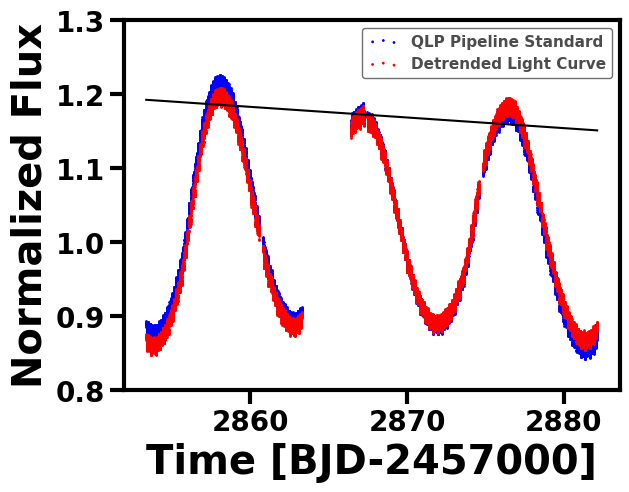

In [14]:
fig, ax = plt.subplots(1, 1)
fluxnew = cepheidfl/linfit_wlmodel(xaxis)
tesslc2 = lk.LightCurve(time=cepheidday, flux = fluxnew).normalize()

tesslc.scatter(ax=ax, c='b', label='QLP Pipeline Standard')
tesslc2.scatter(ax=ax, c='r', label='Detrended Light Curve')
plt.plot(xaxis, linfit_wlmodel(xaxis), c='k', label = 'Trend Line')

ax.set_ylim(0.8, 1.3)
plt.xlabel(xlabel='Time [BJD-2457000]')


### Now plot the phase fold

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_5069/1848861473.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 1])


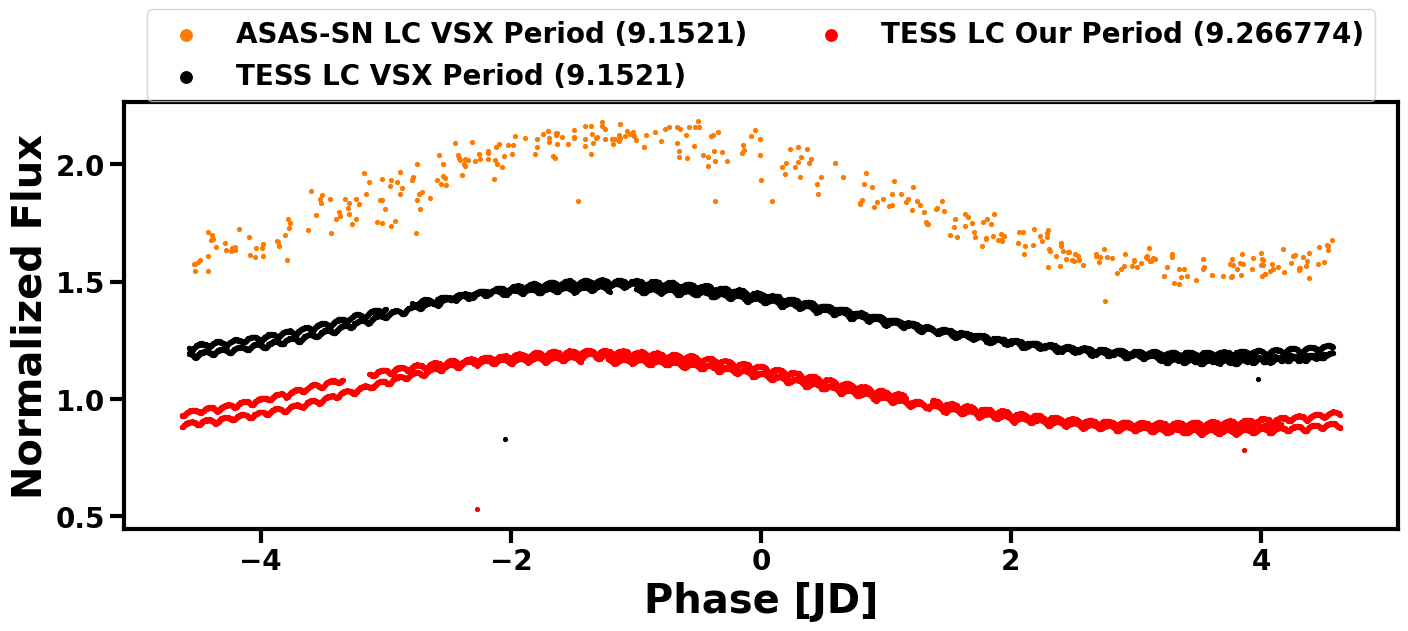

In [16]:
plotter = lcnormed.fold(period=9.1521) #them
tesslc = tesslc2.fold(period=9.1521, epoch_phase=3.2) # them
tesslc22 = tesslc2.fold(period=9.266774, epoch_phase=3.2) # them

fig, ax = plt.subplots(1, 1, figsize=(15, 7), layout='constrained')
scat = plotter.scatter(ax = ax, s=30, label='ASAS-SN LC VSX Period (9.1521)', c='#FF7B00', offset=0.8, rasterized=True)
scat = tesslc.scatter(ax = ax, s=30,label='TESS LC VSX Period (9.1521)', c='k', offset=0.3, rasterized=True)
scat = tesslc22.scatter(ax = ax, s=30,label='TESS LC Our Period (9.266774)', c='r', rasterized=True)

ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('ceph_phasefold.pdf', dpi=300)

# 2. YSO

In [17]:
# ASAS-SN LC for the YSO is horrible, so we're only going to show the TESS light curve
lc = lk.LightCurve(time=dates[3], flux = fluxes[3], flux_err=errors[3])
lcnormedyso = lc.normalize().remove_outliers()

In [18]:
with fits.open("TIC436243677-YSO/hlsp_tasoc_tess_ffi_tic00436243677-s0006-cam1-ccd4-c1800_tess_v05_ens-lc.fits") as hdul:
    yso_tess = Table.read(hdul, format='fits').to_pandas()

In [19]:
yso_tessflux = yso_tess['FLUX_CORR']
yso_tessdays = yso_tess['TIME']
tesslcyso = lk.LightCurve(time=yso_tessdays, flux = yso_tessflux).remove_outliers()

tesslcyso.flux = tesslcyso.flux/np.nanmean(tesslcyso.flux)

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_5069/3729065667.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 1])


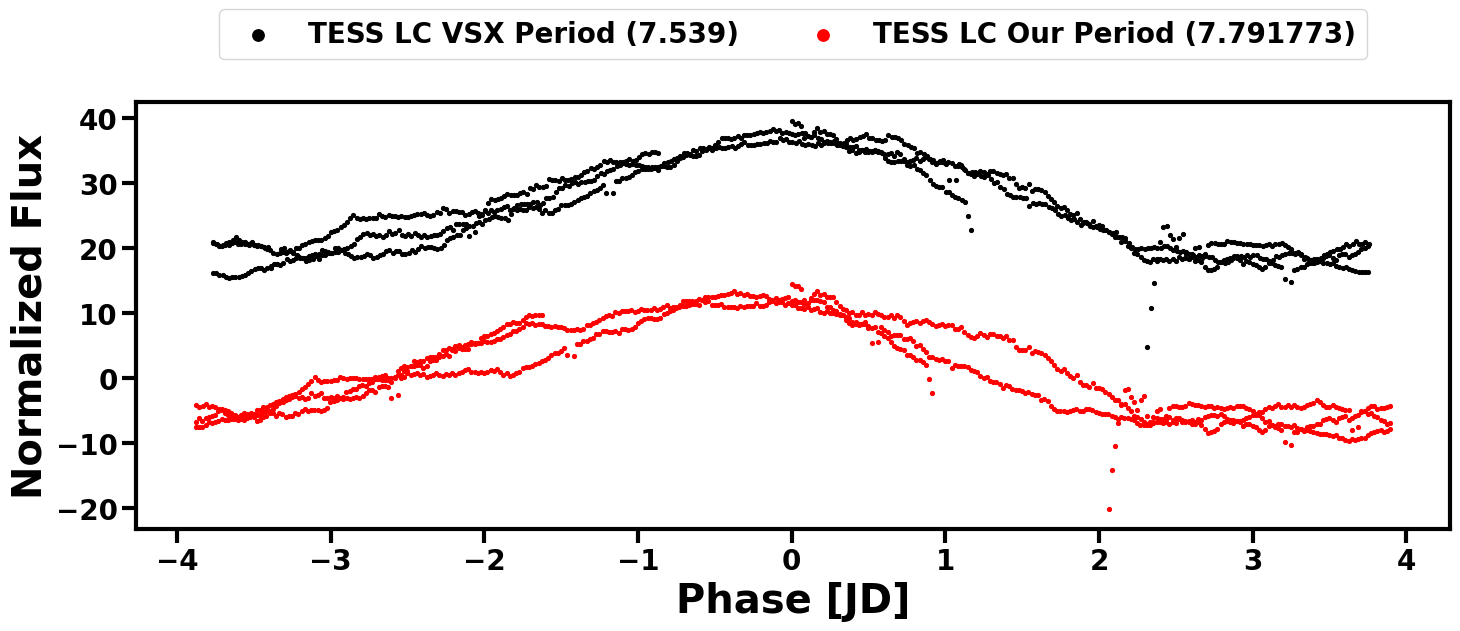

In [20]:
tesslc_them = tesslcyso.fold(period=7.539)#, epoch_phase=-0.9) # them
tesslc_us = tesslcyso.fold(period=7.791773)#, epoch_phase=-0.9) # us

fig, ax = plt.subplots(1, 1, figsize=(15, 7), layout='constrained')

scat = tesslc_them.scatter(ax = ax,s=30, label='TESS LC VSX Period (7.539)', c='k', offset=25, rasterized=True)
scat = tesslc_us.scatter(ax = ax, s=30,label='TESS LC Our Period (7.791773)', c='r', rasterized=True)

ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('yso_phasefold.pdf', dpi=300)

# 3. ROT

In [21]:
# ASAS-SN LC 
lc = lk.LightCurve(time=dates[1], flux = fluxes[1], flux_err=errors[1])
lcnormedrot = lc.normalize().remove_outliers()

In [22]:
with fits.open("TIC6129951-ROT/hlsp_qlp_tess_ffi_s0091-0000000006129951_tess_v01_llc.fits") as hdul:
    rot = Table.read(hdul, format='fits').to_pandas()

In [23]:
rotflux = rot['SAP_FLUX']
rotdays = rot['TIME']
tesslcrot = lk.LightCurve(time=rotdays, flux=rotflux).normalize().remove_outliers()

### Again, divide out the trend

In [25]:
rotdayline = rot['TIME']
xaxisrot = rotdayline
linfit_wlmodelrot = linfitter(model=wlmodel, x=[3778.766541, 3793.338474] , y=[1.085344, 1.169754])
wavelengths = linfit_wlmodelrot(xaxisrot)
linfit_wlmodelrot

<Linear1D(slope=0.00579264, intercept=-20.80370008)>

Text(0.5, 0, 'Time [BJD-2457000]')

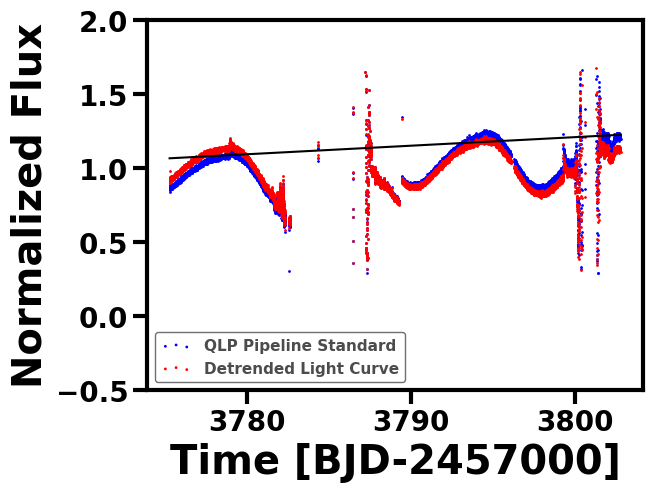

In [26]:
fig, ax = plt.subplots(1, 1)

fluxnew = rotflux/linfit_wlmodelrot(xaxisrot)
tesslcrot2 = lk.LightCurve(time=rotdays, flux=fluxnew).normalize().remove_outliers()

tesslcrot.scatter(ax=ax, c='b', label='QLP Pipeline Standard')
tesslcrot2.scatter(ax=ax, c='r', label='Detrended Light Curve')
plt.plot(xaxisrot, linfit_wlmodelrot(xaxisrot), c='k', label = 'Trend Line')

ax.set_ylim(-0.5, 2)
plt.xlabel(xlabel='Time [BJD-2457000]')

### Create sin waves to overplot at the periods (both VCX and ours)

In [33]:
amplitude = 0.1
period1 = 7.7504
period2 = 8.108467

B1 = 2 * np.pi / period1
B2 = 2 * np.pi / period2
# Create x-values
x = np.linspace(-4, 4, 1000)

# Calculate y-values
y1 = amplitude * np.sin(B1 * x)
y2 = amplitude * np.sin(B2 * (x-5)) #phase offset by 5 days to make the wave line up with the measurements

### Phase folded plot

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_5069/3945899700.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 1])


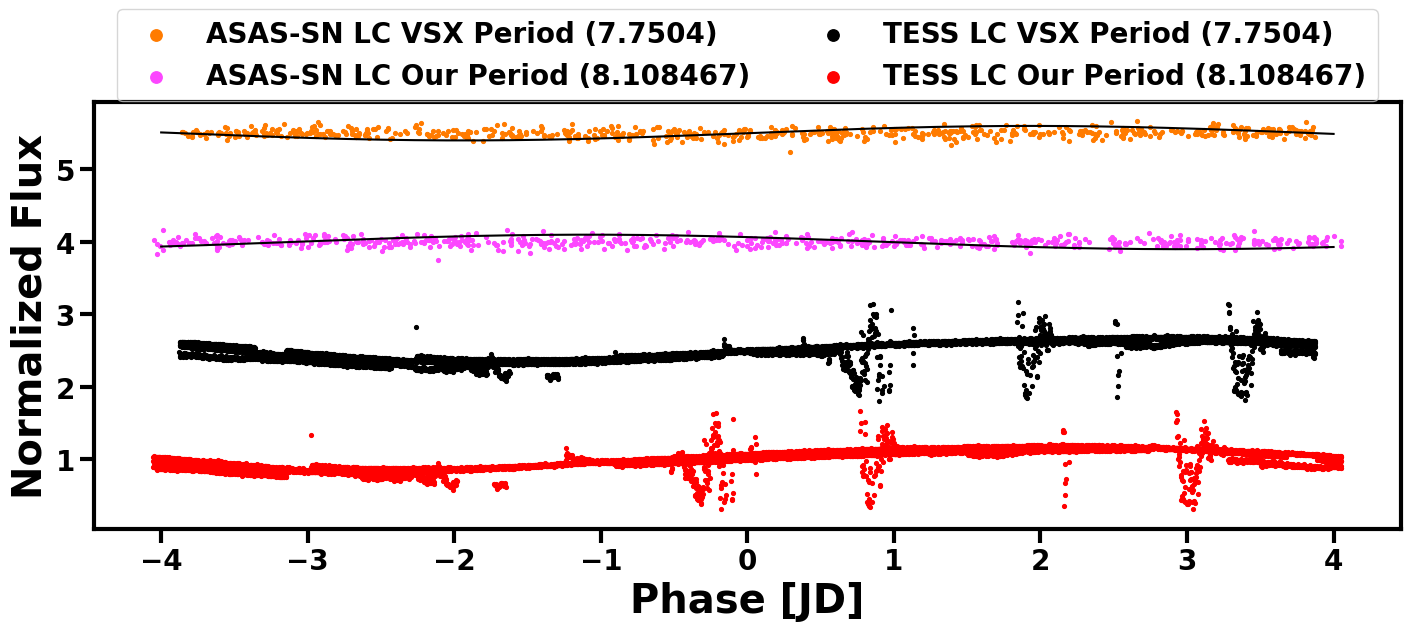

In [34]:
plotter = lcnormedrot.fold(period=7.7504) #them
plotter2 = lcnormedrot.fold(period=8.108467) #us
tesslcxcatrot = tesslcrot2.fold(period=7.7504, epoch_phase=-0.9) # them
tesslcuscatrot = tesslcrot2.fold(period=8.108467, epoch_phase=-0.9) # us

fig, ax = plt.subplots(1, 1, figsize=(15, 7), layout='constrained')

scat = plt.plot(x, y1+5.5, 'k-', rasterized=True)
scat = plt.plot(x, y2+4, 'k-', rasterized=True)
scat = plotter.scatter(ax = ax,  s=30, label='ASAS-SN LC VSX Period (7.7504)', c="#FF7B00", offset=4.5, rasterized=True)
scat = plotter2.scatter(ax = ax, s=30,label='ASAS-SN LC Our Period (8.108467)', c="#fc47ff", offset=3, rasterized=True)

scat = tesslcxcatrot.scatter(ax = ax,s=30, label='TESS LC VSX Period (7.7504)', c='k', offset=1.5, rasterized=True)
scat = tesslcuscatrot.scatter(ax = ax, s=30,label='TESS LC Our Period (8.108467)', c='r', rasterized=True)

ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('rot_phasefold.pdf', dpi=300)

# 4. EB-Algol Type

In [29]:
# ASAS-SN LC 
lc = lk.LightCurve(time=dates[3], flux = fluxes[3], flux_err=errors[3])
lcnormedeb = lc.normalize().remove_outliers()

In [30]:
with fits.open("TIC397585242-EA/hlsp_qlp_tess_ffi_s0070-0000000397585242_tess_v01_llc.fits") as hdul:
    eb = Table.read(hdul, format='fits').to_pandas()

In [31]:
tesslcflux = eb['SAP_FLUX']
tesslctime = eb['TIME']
tesslceb = lk.LightCurve(time=tesslctime, flux=tesslcflux).normalize().remove_outliers()

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_5069/3100672496.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 1])


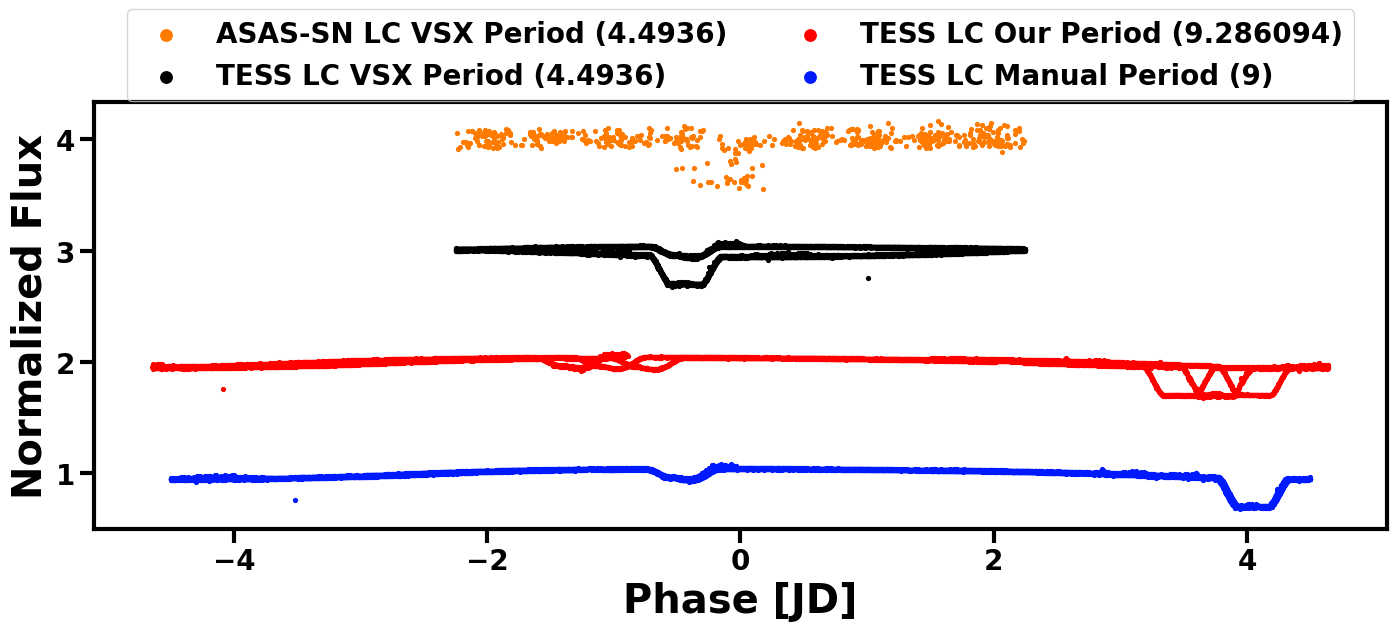

In [32]:
plotter = lcnormedeb.fold(period=4.4936, epoch_phase=1.5) #them
tesslcxcateb = tesslceb.fold(period=4.4936, epoch_phase=1.5) # them
tesslcuscateb = tesslceb.fold(period=9.286094, epoch_phase=1.5) # us
tesslcmanualeb = tesslceb.fold(period=9, epoch_phase=1.5) # manual


fig, ax = plt.subplots(1, 1, figsize=(15, 7), layout='constrained')


scat = plotter.scatter(ax = ax, s=30, label='ASAS-SN LC VSX Period (4.4936)', c='#FF7B00', offset=3, rasterized=True)
scat = tesslcxcateb.scatter(ax = ax, s=30, label='TESS LC VSX Period (4.4936)', c='k', offset=2, rasterized=True)
scat = tesslcuscateb.scatter(ax = ax, s=30, label='TESS LC Our Period (9.286094)', c='r', offset=1, rasterized=True)
scat = tesslcmanualeb.scatter(ax = ax, s=30, label='TESS LC Manual Period (9)', c="#001aff", rasterized=True)


ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('eb_phasefold.pdf', dpi=300)